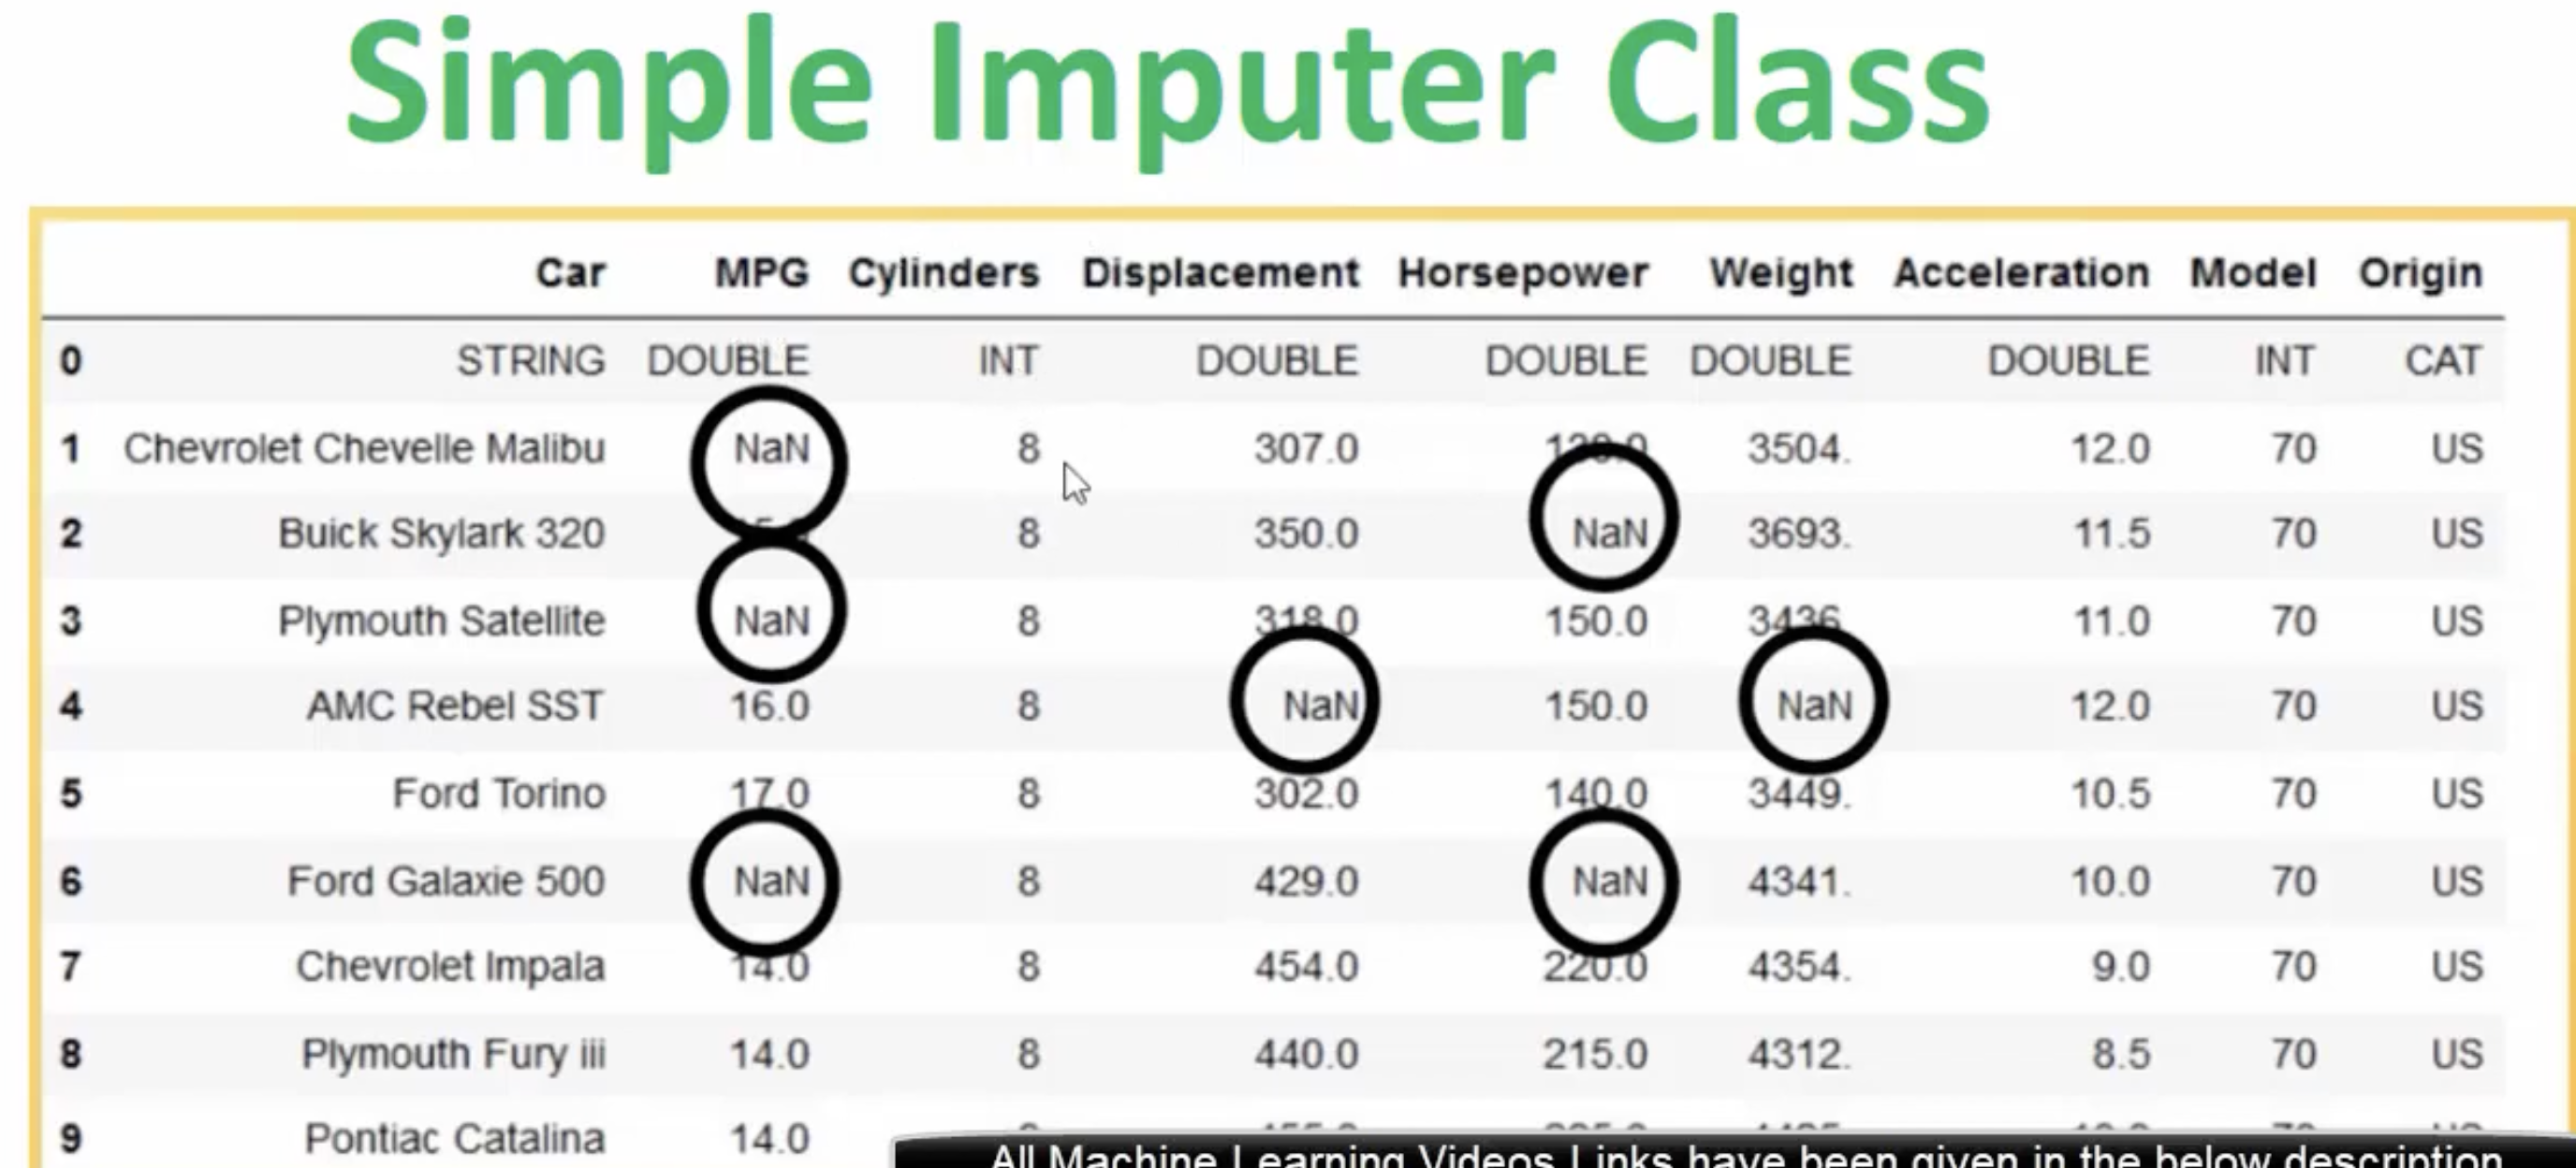

## What is Imputation?

Imputation means replacing missing values (NaN) with estimated values instead of removing rows or columns.

sklearn.impute Module

Main classes:

1-SimpleImputer

2-KNNImputer

3-IterativeImputer

4-MissingIndicator

In [6]:
import matplotlib.pyplot as plt
import pandas as pd 
import numpy as np 
df = pd.DataFrame({ "Age":[25,30,np.nan,40,35], "Salary":[50000,np.nan,70000,80000,60000], "Experience":[2,2,2,np.nan,5] }) 
print(df)

    Age   Salary  Experience
0  25.0  50000.0         2.0
1  30.0      NaN         2.0
2   NaN  70000.0         2.0
3  40.0  80000.0         NaN
4  35.0  60000.0         5.0


In [7]:
df.isnull().sum()

Age           1
Salary        1
Experience    1
dtype: int64

## Simple Imputor

Most commonly used imputer.

It replaces missing values using descriptive statistics.

Strategies:

1-mean

2-median

3-most_frequent

4-constant

class sklearn.impute.SimpleImputer(missing_values=nan,strategy='median')

## Mean Imputation

missing value = column mean

In [8]:
from sklearn.impute import SimpleImputer
imputer=SimpleImputer(strategy='mean')
df[['Age']]=imputer.fit_transform(df[['Age']])
print(df)

    Age   Salary  Experience
0  25.0  50000.0         2.0
1  30.0      NaN         2.0
2  32.5  70000.0         2.0
3  40.0  80000.0         NaN
4  35.0  60000.0         5.0


## Q When to Use Mean Imputation?

Use when:

1-Data is approximately normally distributed

2-No major outliers exist

Example:

Height

Weight

Temperature

## Q When NOT to Use Mean Imputation ?

Example:

Salary

30000
35000
40000
5000000

Mean becomes heavily distorted.

## Median Imputation

missing value = median

In [9]:
from sklearn.impute import SimpleImputer
imputer=SimpleImputer(strategy='median')
df[['Salary']]=imputer.fit_transform(df[['Salary']])
print(df)

    Age   Salary  Experience
0  25.0  50000.0         2.0
1  30.0  65000.0         2.0
2  32.5  70000.0         2.0
3  40.0  80000.0         NaN
4  35.0  60000.0         5.0


## Q Why Median?
Median is robust against outliers.

Example:

30,000
35,000
40,000
5,000,000

Median: 37,500

Mean: 1,276,250

Best For:

1-Income

2-House prices

3-Transaction values

## Mode Imputation

In [18]:
from sklearn.impute import SimpleImputer
data = pd.DataFrame({ "City":["Delhi","Mumbai",np.nan,"Delhi","Delhi"] })
imputer=SimpleImputer(strategy='most_frequent')
data

,City
0,Delhi
1,Mumbai
2,NaN
3,Delhi
4,Delhi


In [19]:
data[['City']]=imputer.fit_transform(data[['City']])
data

,City
0,Delhi
1,Mumbai
2,Delhi
3,Delhi
4,Delhi


In [20]:
imputer.statistics_

array(['Delhi'], dtype=object)

## Mode imputation is Best For:

1-Gender

2-City

3-Product Category

4-Country

## Constant Imputation

In [16]:
data = pd.DataFrame({ "City":["Delhi","Mumbai",np.nan,"Delhi","Delhi"] })

imputer=SimpleImputer(strategy='constant',fill_value='unknown')
data[['City']]=imputer.fit_transform(data[['City']])
data

,City
0,Delhi
1,Mumbai
2,unknown
3,Delhi
4,Delhi


Common Examples

Numerical: fill_value=0

Categorical: fill_value='Missing'

## Important Attribute of SimpleImputer

imputer.statistics_

In [17]:
imputer.statistics_

array(['unknown'], dtype=object)

## KNN Imputation

Parameters:

KNNImputer(n_neighbors=5,weights='uniform')

weights:

uniform

distance

## Advantages:

1-Preserves relationships between variables.

2-Often better than mean imputation.

## Disadvantages:

1-Computationally expensive.

2-Sensitive to scaling.


## Important:Scale data before KNN imputation if features have different units.

In [22]:
## Uses K nearest neighbors to estimate missing values.


# Age	Salary
# 25	50000
# 26	52000
# 27	NaN

# KNN finds similar rows and estimates the value.

In [ ]:
from sklearn.impute import KNNImputer
imputer=KNNImputer(n_neighbors=2) ## checks 2 neighbours

In [26]:
df = pd.DataFrame({ "Age":[25,30,np.nan,40,35], "Salary":[50000,np.nan,70000,80000,60000], "Experience":[1,2,3,np.nan,5] }) 
df_imputed=imputer.fit_transform(df)
df

,Age,Salary,Experience
0,25.0,50000.0,1.0
1,30.0,NaN,2.0
2,NaN,70000.0,3.0
3,40.0,80000.0,NaN
4,35.0,60000.0,5.0


In [27]:
df_imputed

array([[2.5e+01, 5.0e+04, 1.0e+00],
       [3.0e+01, 5.0e+04, 2.0e+00],
       [2.5e+01, 7.0e+04, 3.0e+00],
       [4.0e+01, 8.0e+04, 1.0e+00],
       [3.5e+01, 6.0e+04, 5.0e+00]])

## IterativeImputer

One of the most powerful imputers.

## Also known as:MICE (Multiple Imputation by Chained Equations)

Idea

Predict missing values using other features.

In [34]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
df = pd.DataFrame({ "Age":[25,30,50,40,35], "Salary":[50000,70000,np.nan,80000,60000], "Experience":[2,2,8,4,5] }) 
df

,Age,Salary,Experience
0,25,50000.0,2
1,30,70000.0,2
2,50,NaN,8
3,40,80000.0,4
4,35,60000.0,5


In [ ]:
# The important part is: from sklearn.experimental import enable_iterative_imputer
# must come before: from sklearn.impute import IterativeImputer
# IterativeImputer uses a technique similar to MICE (Multiple Imputation by Chained Equations). Since the scikit-learn developers still consider its API subject to change, they require users to explicitly opt in to using it.

In [37]:
iterator=IterativeImputer(random_state=42)
df_imputed=iterator.fit_transform(df)
df_imputed

array([[2.50000000e+01, 5.00000000e+04, 2.00000000e+00],
       [3.00000000e+01, 7.00000000e+04, 2.00000000e+00],
       [5.00000000e+01, 6.50000621e+04, 8.00000000e+00],
       [4.00000000e+01, 8.00000000e+04, 4.00000000e+00],
       [3.50000000e+01, 6.00000000e+04, 5.00000000e+00]])

In [38]:
# Internal Working
# Example:
# Missing Salary
#       ↓
# Train model using Age + Experience
#       ↓
# Predict Salary

## Advantages:
Uses feature relationships.
Usually produces high-quality imputations.

## Disadvantages
Slow on large datasets.
More complex.

## MissingIndicator

Instead of replacing missing values, create a feature showing whether data was missing.

In [ ]:
from sklearn.impute import MissingIndicator
df = pd.DataFrame({ "Age":[25,30,np.nan,40,35], "Salary":[50000,np.nan,70000,80000,60000], "Experience":[2,2,2,np.nan,5] }) 
indicator = MissingIndicator()
missing_features=indicator.fit_transform(df)
missing_features

array([[False, False, False],
       [False,  True, False],
       [ True, False, False],
       [False, False,  True],
       [False, False, False]])

Why Use It?
Sometimes missingness itself contains information.

Example:

Income missing → customer refused to disclose

That may itself be predictive.

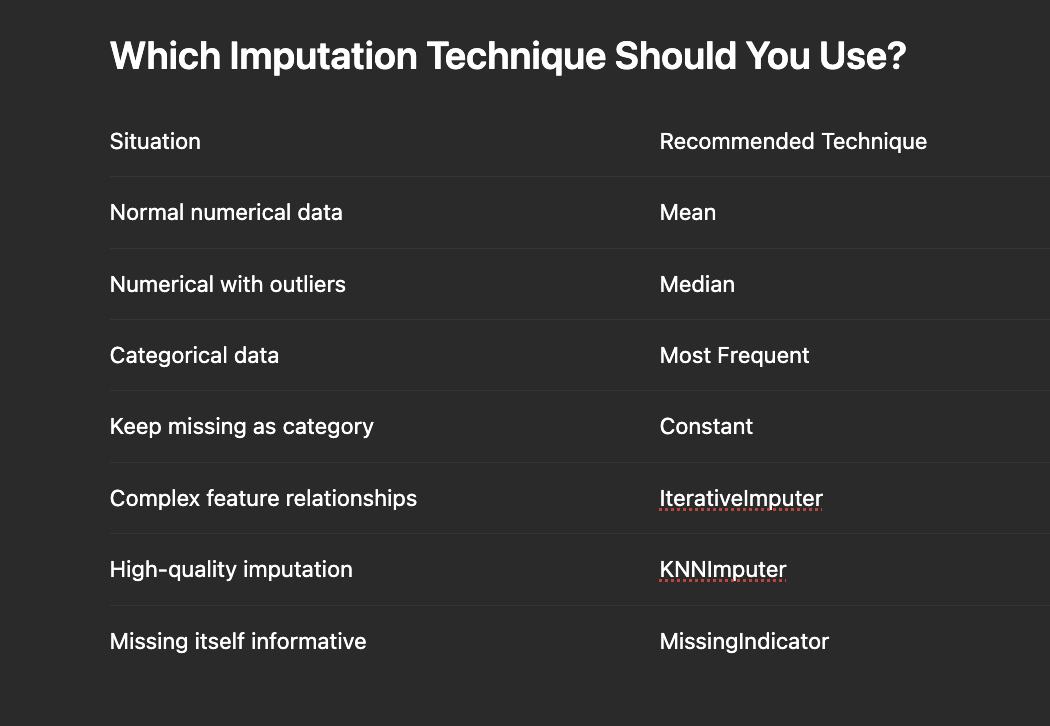